In [251]:
# ... existing code ...
# Read the binary file
with open('mmapped_impl_test.bin', 'rb') as f:
    # Reading the file produces a bytes object.
    # Converting it to a list creates an array of integers (0s and 1s).
    data_array = list(f.read())

# Verify the data
print(f"Read {len(data_array)} bytes")
print(f"First 10 values: {data_array[:10]}")

Read 343067 bytes
First 10 values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [252]:
import matplotlib.pyplot as plt
import seaborn as sns

In [253]:

def observe_slice(start, end):
    slice_to_observe = data_array[start:end]
    plt.plot([i * 20 / 1000.0 for i in range(0, len(slice_to_observe))], slice_to_observe)
    plt.xlabel('Approximate Time (ms)')


In [254]:
starts = []
ends = []

start_index = 0
last_one = 0
i = 0
while start_index < len(data_array):
    while start_index < len(data_array) and data_array[start_index] != 1:
        start_index += 1

    if start_index == len(data_array):
        break
    starts.append(start_index)
    last_one = start_index
    for i in range(start_index, len(data_array)):
        if data_array[i] == 1:
            last_one = i

        if i - last_one > 3500:
            ends.append(last_one)
            break
    start_index = i + 1



In [255]:
len(starts), len(ends)

(4, 4)

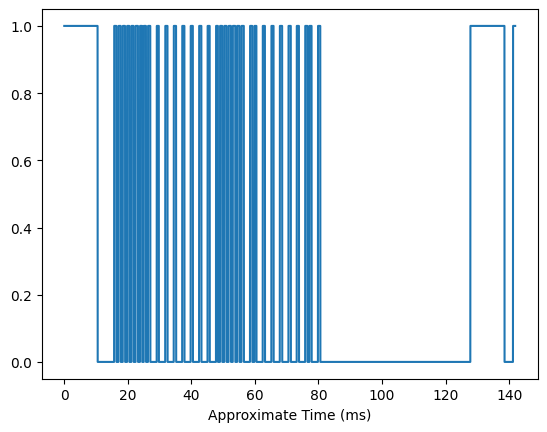

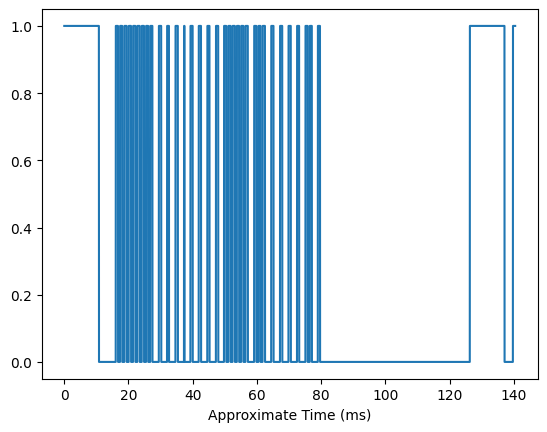

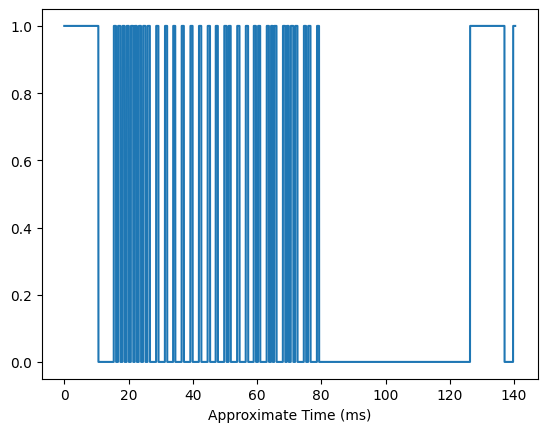

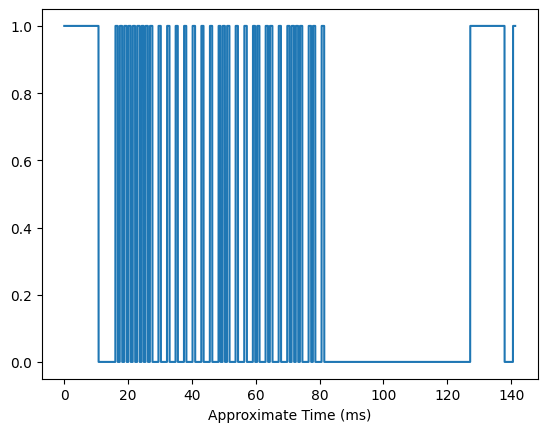

In [256]:
for i in range(len(starts)):
    observe_slice(starts[i], ends[i])
    plt.show()

In [257]:
pulses = []

for i in range(0, len(starts), 1):
    last = 0
    count = 0
    for d in range(starts[i], ends[i]):
        if last == 0 and data_array[d] == 1:
            count += 1
        last = data_array[d]
    pulses.append(count)

In [258]:
pulses

[36, 36, 36, 36]